# Speech Enhancement — MLP Baseline
### Supervised denoising via Ideal Ratio Mask (IRM) prediction

This notebook walks through the complete pipeline of a supervised speech-enhancement system:
from dataset construction and model architecture, through training dynamics, to perceptual evaluation and audio comparison.

**Models compared**
| Model | Type |
|---|---|
| Noisy baseline | No processing |
| Spectral Subtraction (SS) | Classical signal processing |
| Geometric Spectral Subtraction (GSS) | Classical signal processing |
| **MLP (IRM masking)** | **Supervised deep learning** |

---


## 1. Environment setup

In [12]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import soundfile as sf
import librosa
import librosa.display
import json
from pathlib import Path
from IPython.display import Audio, display, HTML
import os

# ── Paths ──────────────────────────────────────────────────────────────────
REPO_ROOT = Path(os.getcwd()).parent

CLEAN_DIR   = REPO_ROOT / "data" / "raw" / "wavs" / "test" / "clean"
NOISY_DIR   = REPO_ROOT / "data" / "raw" / "wavs" / "test" / "noisy"
MODEL_DIR   = REPO_ROOT / "outputs" / "models" / "mlp"
RESULTS_DIR = REPO_ROOT / "outputs" / "results"

EXAMPLE_FILES = ["00005.wav", "00009.wav"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Librosa: {librosa.__version__}")

Device : cpu
PyTorch: 2.11.0+cpu
Librosa: 0.11.0


## 2. Core concepts

### 2.1 Why masking instead of mapping?

Rather than trying to *generate* clean speech (a very hard regression problem), we ask the model a simpler question:
**"For each time-frequency bin, how much of the signal should I keep?"**

The answer is a soft mask $M(t,f) \in [0,1]$ applied to the noisy magnitude spectrogram:

$$\hat{S}(t,f) = M(t,f) \cdot |Y(t,f)| \cdot e^{j\angle Y(t,f)}$$

This is called the **masking approach**. It preserves the original phase (a practical choice; phase estimation is notoriously hard) and constrains the model to *attenuate* rather than hallucinate energy.

---

### 2.2 The Ideal Ratio Mask (IRM)

The training *target* is the theoretically optimal soft mask given access to clean speech $S$ and noise $N$:

$$\text{IRM}(t,f) = \sqrt{\frac{|S(t,f)|^2}{|S(t,f)|^2 + |N(t,f)|^2}}$$

- A value of **1.0** means "this bin is dominated by speech — keep it fully."
- A value of **0.0** means "this bin is dominated by noise — suppress it completely."
- The square root spreads the distribution away from the extremes, giving the model a smoother target to learn.

> The IRM is computed from oracle clean and noisy spectrograms **only during training**. At inference time we predict it from the noisy signal alone.

---

### 2.3 Log-magnitude features

Human hearing is approximately logarithmic in loudness. Training on log-magnitude spectrograms:
- Compresses the dynamic range (~120 dB → ~12 dB effective range)
- Makes quieter phonemes equally important during learning
- Improves gradient flow through the network


## 3. Dataset construction

In [13]:
# ── STFT parameters (must match training) ─────────────────────────────────
SR         = 16_000   # sample rate (Hz)
N_FFT      = 512      # FFT window size  →  257 unique frequency bins
HOP_LENGTH = 128      # hop = N_FFT / 4  →  ~8 ms resolution at 16 kHz
FREQ_BINS  = N_FFT // 2 + 1   # 257
CONTEXT    = 5                 # frames of context on each side
WINDOW     = 2 * CONTEXT + 1  # 11-frame temporal window

print("STFT configuration")
print(f"  Sample rate    : {SR:,} Hz")
print(f"  FFT size       : {N_FFT}  →  {FREQ_BINS} frequency bins")
print(f"  Hop length     : {HOP_LENGTH} samples  ({HOP_LENGTH/SR*1000:.1f} ms)")
print(f"  Context window : {CONTEXT} frames each side  ({WINDOW} total)")
print(f"  MLP input dim  : {WINDOW} × {FREQ_BINS} = {WINDOW * FREQ_BINS}")


STFT configuration
  Sample rate    : 16,000 Hz
  FFT size       : 512  →  257 frequency bins
  Hop length     : 128 samples  (8.0 ms)
  Context window : 5 frames each side  (11 total)
  MLP input dim  : 11 × 257 = 2827


### 3.1 Temporal context

A single spectrogram frame captures only a ~32 ms snapshot.
Speech phonemes have structure that spans 100–300 ms, so the model benefits from seeing **surrounding frames**.

We concatenate 5 frames before and 5 after the target frame, forming an **11 × 257 = 2,827-dimensional input vector**.
This in theory gives the MLP enough temporal context to distinguish transient speech onsets from steady-state noise.


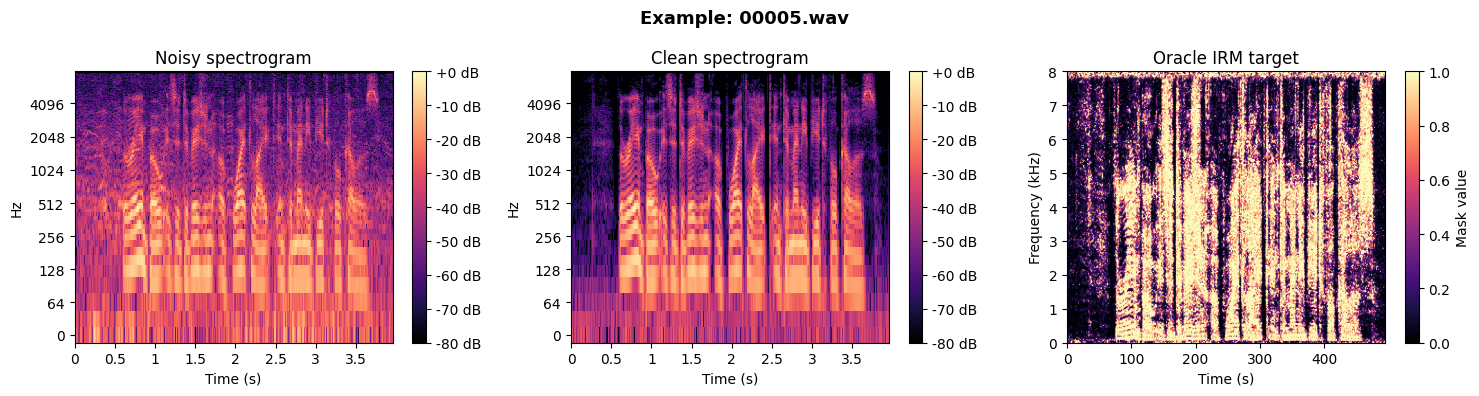

IRM statistics:  min=0.000  mean=0.519  max=1.000
Bins near 1.0 (speech-dominant): 36.6%
Bins near 0.0 (noise-dominant):  33.8%


In [15]:
# ── Visualise an example noisy/clean pair ─────────────────────────────────
example_clean = CLEAN_DIR / EXAMPLE_FILES[0]
example_noisy = NOISY_DIR / EXAMPLE_FILES[0]

y_clean, _ = sf.read(example_clean)
y_noisy, _ = sf.read(example_noisy)

D_clean = librosa.stft(y_clean.astype(np.float64), n_fft=N_FFT, hop_length=HOP_LENGTH)
D_noisy = librosa.stft(y_noisy.astype(np.float64), n_fft=N_FFT, hop_length=HOP_LENGTH)

mag_clean = np.abs(D_clean)
mag_noisy = np.abs(D_noisy)

# Ideal Ratio Mask (oracle)
clean_pow  = mag_clean ** 2
noise_pow  = np.maximum(mag_noisy ** 2 - clean_pow, 1e-10)
irm_oracle = np.sqrt(clean_pow / (clean_pow + noise_pow + 1e-10)).clip(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, mag, title in zip(
    axes,
    [mag_noisy, mag_clean, irm_oracle],
    ["Noisy spectrogram", "Clean spectrogram", "Oracle IRM target"]
):
    if title.startswith("Oracle"):
        img = ax.imshow(mag, origin="lower", aspect="auto",
                        vmin=0, vmax=1, cmap="magma",
                        extent=[0, mag.shape[1], 0, SR/2/1000])
        ax.set_ylabel("Frequency (kHz)")
        fig.colorbar(img, ax=ax, label="Mask value")
    else:
        db = librosa.amplitude_to_db(mag, ref=np.max)
        img = librosa.display.specshow(db, sr=SR, hop_length=HOP_LENGTH,
                                       x_axis="time", y_axis="log", ax=ax)
        fig.colorbar(img, ax=ax, format="%+2.0f dB")
    ax.set_title(title)
    ax.set_xlabel("Time (s)")

plt.suptitle(f"Example: {EXAMPLE_FILES[0]}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"IRM statistics:  min={irm_oracle.min():.3f}  mean={irm_oracle.mean():.3f}  max={irm_oracle.max():.3f}")
print(f"Bins near 1.0 (speech-dominant): {(irm_oracle > 0.8).mean()*100:.1f}%")
print(f"Bins near 0.0 (noise-dominant):  {(irm_oracle < 0.2).mean()*100:.1f}%")

### 3.2 Noise spectrum analysis

Before training, it is worth inspecting the **spectral shape of the noise** in the dataset.
Understanding where noise energy lives tells us what the IRM target will look like — and
explains any patterns we observe in the oracle mask.

The plot below shows the average noise magnitude spectrum across the example file,
computed as:

$$\hat{N}(f) = \frac{1}{T} \sum_t \max\bigl(|Y(t,f)| - |S(t,f)|,\ 0\bigr)$$

**What to observe:**

- The noise is **heavily low-frequency dominated**, with a sharp peak below 0.5 kHz and
  energy decaying above 1 kHz, but approaching 0 very closely around 7.8Khz.
- This explains the **horizontal band of IRM ≈ 1.0 visible above ~7.8 kHz** in the oracle
  mask: the noise contributes negligible energy at those frequencies, so the mask correctly
  instructs the model to keep everything there untouched.
- The large spike near 0 Hz is consistent with low-frequency hum or room noise — the model
  should learn to suppress these bins most aggressively.
- Mid-range speech formants (1–4 kHz) sit in a region of moderate noise, where the IRM
  takes intermediate values and the model's prediction is most consequential for perceived
  speech quality.

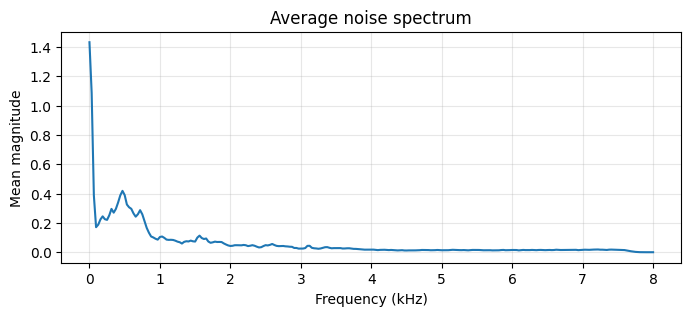

In [16]:
noise_mag = np.maximum(np.abs(D_noisy) - np.abs(D_clean), 0)
avg_noise_spectrum = noise_mag.mean(axis=1)  # average over time

plt.figure(figsize=(8, 3))
freqs = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)
plt.plot(freqs / 1000, avg_noise_spectrum)
plt.xlabel("Frequency (kHz)")
plt.ylabel("Mean magnitude")
plt.title("Average noise spectrum")
plt.grid(alpha=0.3)
plt.show()

## 4. Model architecture

In [17]:
class SpeechMLP(nn.Module):
    """
    4-layer MLP for IRM-based speech enhancement.

    Architecture:
        Input → [Linear → BatchNorm1d → LeakyReLU(0.1) → Dropout(0.2)] × 4
              → Linear → Sigmoid

    Key choices
    -----------
    BatchNorm1d  Normalises activations within each mini-batch, stabilising
                 training and allowing higher learning rates.
    LeakyReLU    Avoids dead neurons (gradient = 0.1 for negative inputs)
                 compared with standard ReLU.
    Sigmoid      Constrains the output to [0, 1] — exactly the IRM range.
    Dropout(0.2) Regularises the dense layers to prevent overfitting on
                 speaker-specific patterns.
    """

    def __init__(self, input_dim: int, output_dim: int = 257,
                 hidden_dim: int = 1024, n_layers: int = 4,
                 dropout: float = 0.2):
        super().__init__()
        layers = []
        layers += [nn.Linear(input_dim, hidden_dim),
                   nn.BatchNorm1d(hidden_dim),
                   nn.LeakyReLU(negative_slope=0.1),
                   nn.Dropout(dropout)]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim),
                       nn.BatchNorm1d(hidden_dim),
                       nn.LeakyReLU(negative_slope=0.1),
                       nn.Dropout(dropout)]
        layers += [nn.Linear(hidden_dim, output_dim), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="leaky_relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


INPUT_DIM = WINDOW * FREQ_BINS   # 11 × 257 = 2827
model_info = SpeechMLP(input_dim=INPUT_DIM)

print("─" * 50)
print("SpeechMLP — layer summary")
print("─" * 50)
total = 0
for name, p in model_info.named_parameters():
    n = p.numel()
    total += n
    print(f"  {name:<35} {str(list(p.shape)):<20}  {n:>10,}")
print("─" * 50)
print(f"  {'TOTAL':35}  {'':20}  {total:>10,}")

──────────────────────────────────────────────────
SpeechMLP — layer summary
──────────────────────────────────────────────────
  net.0.weight                        [1024, 2827]           2,894,848
  net.0.bias                          [1024]                     1,024
  net.1.weight                        [1024]                     1,024
  net.1.bias                          [1024]                     1,024
  net.4.weight                        [1024, 1024]           1,048,576
  net.4.bias                          [1024]                     1,024
  net.5.weight                        [1024]                     1,024
  net.5.bias                          [1024]                     1,024
  net.8.weight                        [1024, 1024]           1,048,576
  net.8.bias                          [1024]                     1,024
  net.9.weight                        [1024]                     1,024
  net.9.bias                          [1024]                     1,024
  net.12.weight     

### Architecture rationale

| Design choice | Why |
|---|---|
| **4 hidden layers × 1024 units** | Deep enough to learn nonlinear spectro-temporal patterns; wide enough to avoid information bottlenecks |
| **Input dim = 2,827** | 11 frames × 257 bins — captures ~88 ms of context |
| **Output dim = 257** | One mask value per frequency bin |
| **Kaiming initialisation** | Variance-preserving init for LeakyReLU activations; prevents vanishing gradients at layer 1 |
| **Sigmoid output** | Hard constraint: mask ∈ [0,1] by design, not by loss penalty |


$$\begin{array}{c}
\text{{\bf Input Layer}} \\
\underbrace{\circ \circ \circ \dots \dots \dots \circ}_{2827} \\
\text{\small (11 Frames } \times \text{ 257 Bins)} \\
\downarrow \\
\text{{\bf Hidden Layer 1}} \\
\underbrace{\bullet \bullet \bullet \dots \bullet}_{1024} \\
\downarrow \\
\text{{\bf Hidden Layer 2}} \\
\underbrace{\bullet \bullet \bullet \dots \bullet}_{1024} \\
\downarrow \\
\text{{\bf Hidden Layer 3}} \\
\underbrace{\bullet \bullet \bullet \dots \bullet}_{1024} \\
\downarrow \\
\text{{\bf Hidden Layer 4}} \\
\underbrace{\bullet \bullet \bullet \dots \bullet}_{1024} \\
\downarrow \\
\text{{\bf Output Layer}} \\
\underbrace{\diamond \diamond \dots \diamond}_{257} \\
\text{\small (Predicted IRM Mask)}
\end{array}$$

## 5. Training

In [21]:
# ── Load training log ─────────────────────────────────────────────────────
TRAIN_LOG = REPO_ROOT / "outputs" / "models" / "mlp" / "training_log.json"

with open(TRAIN_LOG) as f:
    log = json.load(f)

train_losses = log["train_losses"]
val_losses   = log["val_losses"]
best_epoch   = log["best_epoch"]
best_val     = log["best_val_loss"]
hp           = log["hyperparameters"]

print("Hyperparameters")
print("─" * 38)
for k, v in hp.items():
    print(f"  {k:<20} {v}")
print(f"\nBest epoch : {best_epoch}")
print(f"Best val MSE: {best_val:.6f}")

Hyperparameters
──────────────────────────────────────
  context_frames       5
  hidden_dim           1024
  n_layers             4
  dropout              0.2
  lr                   0.001
  batch_size           2048

Best epoch : 108
Best val MSE: 0.036705


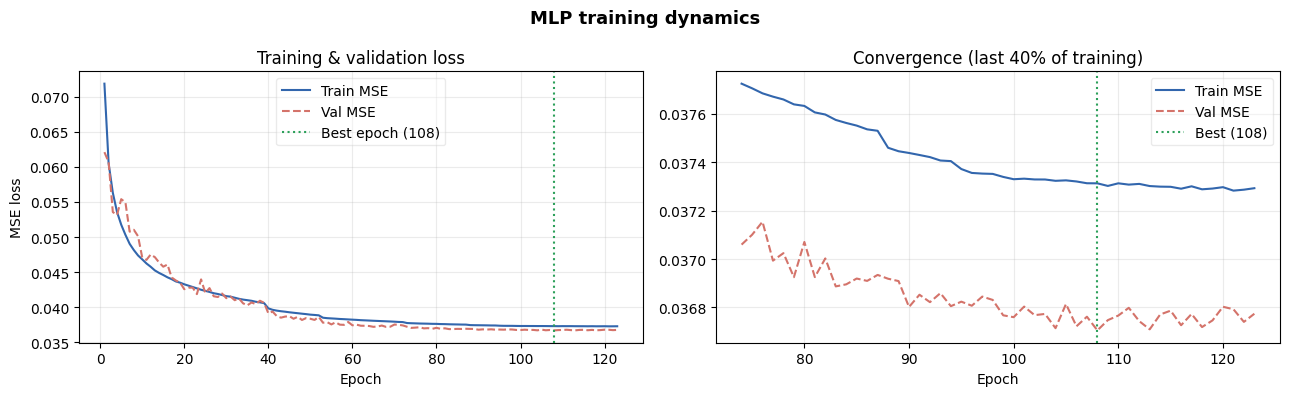

Final train/val gap : -0.000518  (positive = slight overfitting)
Train improvement   : 0.034548
Val   improvement   : 0.025317


In [22]:
# ── Loss curves ───────────────────────────────────────────────────────────
epochs = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full curve
ax = axes[0]
ax.plot(epochs, train_losses, label="Train MSE", linewidth=1.5, color="#3266ad")
ax.plot(epochs, val_losses,   label="Val MSE",   linewidth=1.5, color="#d4736a", linestyle="--")
ax.axvline(best_epoch, color="#2ca05a", linestyle=":", linewidth=1.5,
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Training & validation loss")
ax.legend(framealpha=0.4)
ax.grid(alpha=0.25)

# Zoom: last 30% of training to see convergence behaviour
zoom_start = max(0, int(len(train_losses) * 0.60))
ax = axes[1]
ax.plot(list(epochs)[zoom_start:], train_losses[zoom_start:],
        label="Train MSE", linewidth=1.5, color="#3266ad")
ax.plot(list(epochs)[zoom_start:], val_losses[zoom_start:],
        label="Val MSE",   linewidth=1.5, color="#d4736a", linestyle="--")
ax.axvline(best_epoch, color="#2ca05a", linestyle=":", linewidth=1.5,
           label=f"Best ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_title("Convergence (last 40% of training)")
ax.legend(framealpha=0.4)
ax.grid(alpha=0.25)

plt.suptitle("MLP training dynamics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

gap = [v - t for t, v in zip(train_losses, val_losses)]
print(f"Final train/val gap : {gap[-1]:.6f}  (positive = slight overfitting)")
print(f"Train improvement   : {train_losses[0] - train_losses[-1]:.6f}")
print(f"Val   improvement   : {val_losses[0]   - val_losses[-1]:.6f}")


### Training stability techniques

**MSE loss** is the standard choice for regression; it penalises large mask errors quadratically.

**Adam optimiser** with $lr = 10^{-3}$ adapts per-parameter learning rates, accelerating convergence on the sparse high-frequency bins.

**ReduceLROnPlateau** halves the learning rate after 3 epochs without improvement, allowing fine-grained weight updates near the minimum.

**Gradient clipping** (`max_norm = 5.0`) prevents exploding gradients that can occur when occasional spectrogram outliers produce very large loss spikes.

**Early stopping** (`patience = 15`) halts training when validation loss stops improving, preventing overfitting and saving compute.


## 6. Inference pipeline

At inference time we have **no access to the clean signal**. The pipeline is:

1. Load the noisy `.wav` and compute its STFT
2. Extract log-magnitude frames; normalise with training statistics
3. Feed 11-frame windows through the MLP → predicted IRM mask per frame
4. Apply: `enhanced_mag = noisy_mag × predicted_mask`
5. Reconstruct: `iSTFT(enhanced_mag, noisy_phase)` — the original phase is reused

Phase reuse is a practical approximation. It introduces some residual artefacts but avoids the need for a separate phase estimator, which is an active research problem.


In [25]:
# ── Load model and normalization stats ────────────────────────────────────
NORM_MEAN = MODEL_DIR / "norm_mean.npy"
NORM_STD = MODEL_DIR / "norm_std.npy"
MODEL_PT = MODEL_DIR / "best_model.pt"

mean = np.load(NORM_MEAN)   # shape (257,) — per-bin mean
std  = np.load(NORM_STD)    # shape (257,) — per-bin std

model = SpeechMLP(input_dim=INPUT_DIM).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PT, map_location=DEVICE, weights_only=True))
model.eval()
print(f"Model loaded from  : {MODEL_PT}")
print(f"Parameters         : {model.count_parameters():,}")
print(f"Norm stats shape   : mean={mean.shape}, std={std.shape}")
print(f"Running on         : {DEVICE}")

Model loaded from  : C:\Users\User\Desktop\Applied-ML-Audio-Denoising-RUG-2026\outputs\models\mlp\best_model.pt
Parameters         : 6,316,289
Norm stats shape   : mean=(257,), std=(257,)
Running on         : cpu


In [26]:
def enhance_file(noisy_path, model, mean, std,
                 context=CONTEXT, sr=SR, n_fft=N_FFT, hop=HOP_LENGTH):
    """Enhance a single .wav file. Returns enhanced waveform as float64 array."""
    y, file_sr = sf.read(noisy_path)
    if y.ndim > 1:
        y = y.mean(axis=1)
    if file_sr != sr:
        y = librosa.resample(y, orig_sr=file_sr, target_sr=sr)
    y = y.astype(np.float64)

    D          = librosa.stft(y, n_fft=n_fft, hop_length=hop)
    mag_linear = np.abs(D).astype(np.float32)
    log_mag    = np.log(mag_linear + 1e-9)
    phase      = np.angle(D)

    freq_bins, n_frames = mag_linear.shape

    # Pad log-mag along the time axis so every frame has full context
    pad        = np.zeros((freq_bins, context), dtype=np.float32)
    log_padded = np.concatenate([pad, log_mag, pad], axis=1)

    masks       = np.zeros_like(mag_linear)
    batch_size  = 512
    batch_feats = []
    batch_idx   = []

    for t in range(n_frames):
        # window shape: (11, 257), transposed from (257, 11)
        win_2d = log_padded[:, t : t + 2*context+1].T
        win_norm = (win_2d - mean) / std
        batch_feats.append(win_norm.flatten())
        batch_idx.append(t)

        if len(batch_feats) == batch_size or t == n_frames - 1:
            x = torch.tensor(np.array(batch_feats), dtype=torch.float32).to(DEVICE)
            with torch.no_grad():
                pred = model(x).cpu().numpy()
            for i, fi in enumerate(batch_idx):
                masks[:, fi] = pred[i]
            batch_feats, batch_idx = [], []

    enhanced_mag  = mag_linear * masks
    D_enhanced    = enhanced_mag * np.exp(1j * phase)
    enhanced_wav  = librosa.istft(D_enhanced, hop_length=hop, length=len(y))
    return enhanced_wav.astype(np.float64), masks, mag_linear, phase

print("enhance_file() defined — ready for inference.")

enhance_file() defined — ready for inference.


## 7. Audio examples — listen and compare

In [27]:
results = {}

for fname in EXAMPLE_FILES:
    clean_path = CLEAN_DIR / fname
    noisy_path = NOISY_DIR / fname

    y_clean, _ = sf.read(clean_path)
    y_noisy, _ = sf.read(noisy_path)
    y_clean = y_clean.astype(np.float64)
    y_noisy = y_noisy.astype(np.float64)

    y_enhanced, masks, noisy_mag, phase = enhance_file(noisy_path, model, mean, std)

    results[fname] = dict(clean=y_clean, noisy=y_noisy,
                          enhanced=y_enhanced, masks=masks,
                          noisy_mag=noisy_mag)
    print(f"Enhanced {fname}  — duration: {len(y_clean)/SR:.2f}s")

Enhanced 00005.wav  — duration: 3.96s
Enhanced 00009.wav  — duration: 4.34s


In [28]:
# ── Playback widgets ──────────────────────────────────────────────────────
for fname, r in results.items():
    display(HTML(f"""
    <div style='border:1px solid #ddd; border-radius:8px;
                padding:14px 18px; margin-bottom:16px;
                font-family:sans-serif;'>
      <b style='font-size:15px;'>{fname}</b>
      <table style='margin-top:10px; border-spacing:0 6px;'>
        <tr><td style='width:130px; color:#666; font-size:13px;'>Clean (reference)</td>
            <td id='c_{fname}'></td></tr>
        <tr><td style='color:#666; font-size:13px;'>Noisy (input)</td>
            <td id='n_{fname}'></td></tr>
        <tr><td style='color:#666; font-size:13px;'>MLP enhanced</td>
            <td id='e_{fname}'></td></tr>
      </table>
    </div>
    """))
    print(f"  ▸ Clean — {fname}:")
    display(Audio(r["clean"],   rate=SR))
    print(f"  ▸ Noisy — {fname}:")
    display(Audio(r["noisy"],   rate=SR))
    print(f"  ▸ Enhanced — {fname}:")
    display(Audio(r["enhanced"], rate=SR))
    print()

Clean (reference),
Noisy (input),
MLP enhanced,


  ▸ Clean — 00005.wav:


  ▸ Noisy — 00005.wav:


  ▸ Enhanced — 00005.wav:


Clean (reference),
Noisy (input),
MLP enhanced,


  ▸ Clean — 00009.wav:


  ▸ Noisy — 00009.wav:


  ▸ Enhanced — 00009.wav:


## 8. Spectrogram comparison

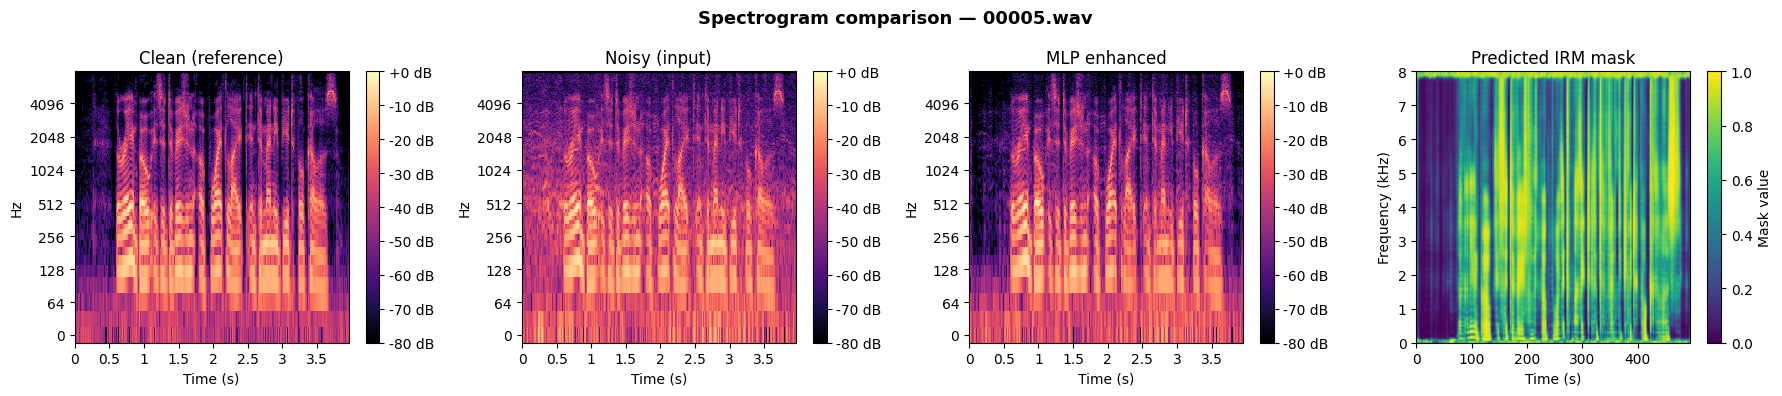

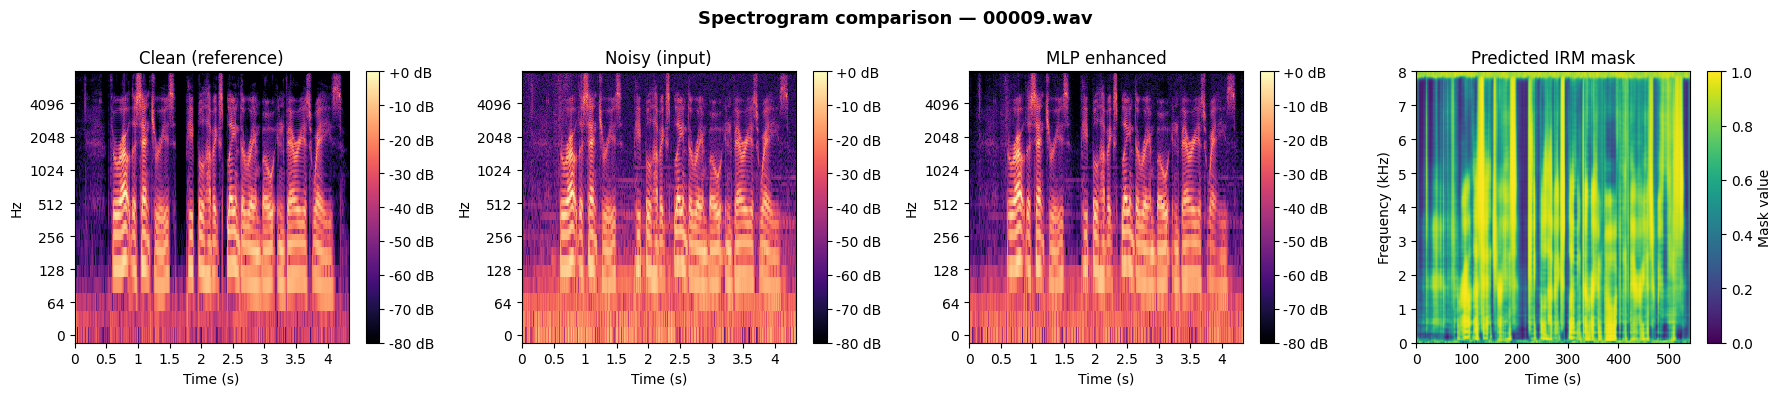

In [29]:
for fname, r in results.items():
    y_clean   = r["clean"]
    y_noisy   = r["noisy"]
    y_enhanced= r["enhanced"]

    D_clean    = librosa.stft(y_clean,    n_fft=N_FFT, hop_length=HOP_LENGTH)
    D_noisy    = librosa.stft(y_noisy,    n_fft=N_FFT, hop_length=HOP_LENGTH)
    D_enhanced = librosa.stft(y_enhanced, n_fft=N_FFT, hop_length=HOP_LENGTH)

    specs  = [np.abs(D_clean), np.abs(D_noisy), np.abs(D_enhanced), r["masks"]]
    titles = ["Clean (reference)", "Noisy (input)",
              "MLP enhanced", "Predicted IRM mask"]
    cmaps  = ["magma", "magma", "magma", "viridis"]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, spec, title, cmap in zip(axes, specs, titles, cmaps):
        if title.endswith("mask"):
            im = ax.imshow(spec, origin="lower", aspect="auto",
                           vmin=0, vmax=1, cmap=cmap,
                           extent=[0, spec.shape[1], 0, SR/2/1000])
            ax.set_ylabel("Frequency (kHz)")
            fig.colorbar(im, ax=ax, label="Mask value")
        else:
            db = librosa.amplitude_to_db(spec, ref=np.max)
            im = librosa.display.specshow(db, sr=SR, hop_length=HOP_LENGTH,
                                          x_axis="time", y_axis="log",
                                          ax=ax, cmap=cmap)
            fig.colorbar(im, ax=ax, format="%+2.0f dB")
        ax.set_title(title)
        ax.set_xlabel("Time (s)")

    plt.suptitle(f"Spectrogram comparison — {fname}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 9. Evaluation metrics

### What each metric measures

| Metric | Range | Higher = better? | What it captures |
|---|---|---|---|
| **PESQ** | −0.5 → 4.5 | ✅ | ITU perceptual speech quality; correlates with MOS listening tests |
| **STOI** | 0 → 1 | ✅ | Short-time objective intelligibility; predicts word recognition |
| **CSIG** | 1 → 5 | ✅ | Signal distortion perceived by listeners |
| **CBAK** | 1 → 5 | ✅ | Background noise intrusiveness |
| **COVL** | 1 → 5 | ✅ | Overall quality (blend of CSIG + CBAK) |
| **SSNR** | dB | ✅ | Segmental SNR — frequency-weighted noise reduction |
| **SI-SDR** | dB | ✅ | Scale-invariant SDR; robust to gain differences |

> **Note on STOI**: the noisy baseline scores *higher* than the MLP on STOI. This is expected — STOI measures intelligibility, and noisy speech is often still fully intelligible. The MLP trades a small intelligibility margin for a significant reduction in perceived noise (PESQ, CBAK).


In [30]:
# ── Load all results ──────────────────────────────────────────────────────
mlp_res = json.load(open(RESULTS_DIR / "mlp.json"))["metrics"]
base_res = json.load(open(RESULTS_DIR / "noisy_baseline.json"))["metrics"]
ss_res   = json.load(open(RESULTS_DIR / "spectral_subtraction.json"))["metrics"]
gss_res  = json.load(open(RESULTS_DIR / "geometric_spectral_subtraction.json"))["metrics"]

models = {
    "Noisy baseline": base_res,
    "Spectral Sub.":  ss_res,
    "Geo. Spec. Sub.": gss_res,
    "MLP (IRM)":       mlp_res,
}
metrics = list(mlp_res.keys())

# Print table
print(f"{'Metric':<10}", end="")
for name in models:
    print(f"  {name:>15}", end="")
print()
print("─" * 75)
for m in metrics:
    print(f"{m:<10}", end="")
    for name, res in models.items():
        v = res.get(m, float("nan"))
        print(f"  {v:>15.4f}", end="")
    print()

Metric       Noisy baseline    Spectral Sub.  Geo. Spec. Sub.        MLP (IRM)
───────────────────────────────────────────────────────────────────────────
PESQ                 1.9707           2.0390           2.2040           2.0879
STOI                 0.9210           0.9140           0.9145           0.8865
CSIG                 4.0657           4.2139           4.3211           4.2427
CBAK                 2.5884           2.6152           2.6925           2.6381
COVL                 3.0795           3.1824           3.3278           3.2254
SSNR                 1.5582           4.5953           5.3644           2.7734
SI_SDR               8.4455          -0.0065           5.9885           8.5756


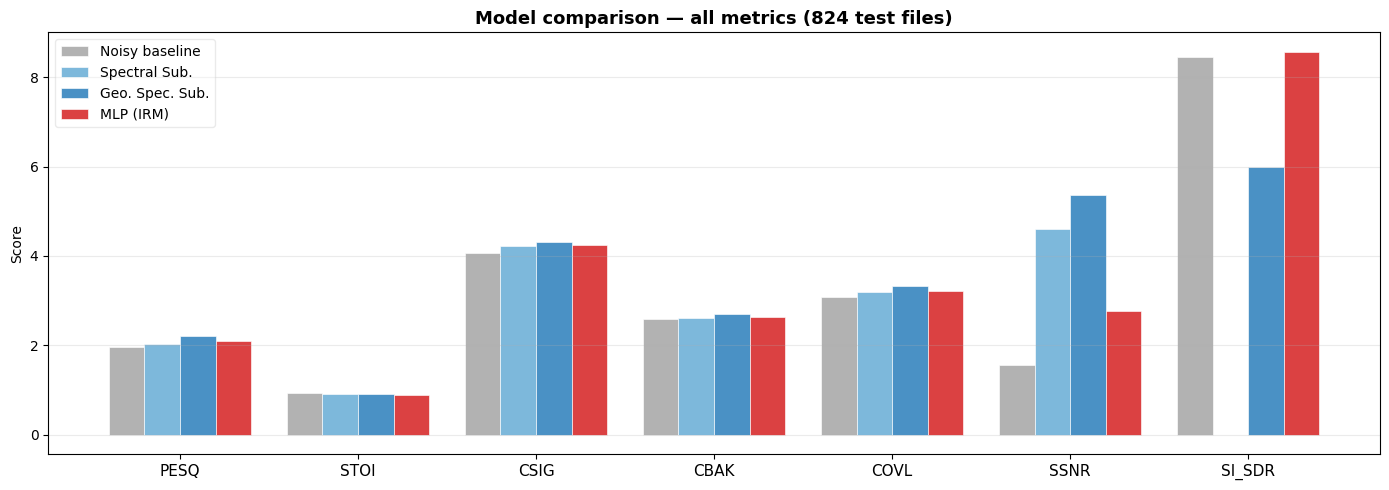

In [31]:
# ── Bar chart: all metrics, all models ───────────────────────────────────
colors = ["#a8a8a8", "#6baed6", "#3182bd", "#d62728"]
x      = np.arange(len(metrics))
width  = 0.2
model_names = list(models.keys())

fig, ax = plt.subplots(figsize=(14, 5))

for i, (name, res) in enumerate(models.items()):
    vals = [res.get(m, 0) for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=colors[i], alpha=0.88, edgecolor="white", linewidth=0.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score")
ax.set_title("Model comparison — all metrics (824 test files)", fontsize=13, fontweight="bold")
ax.legend(framealpha=0.4)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

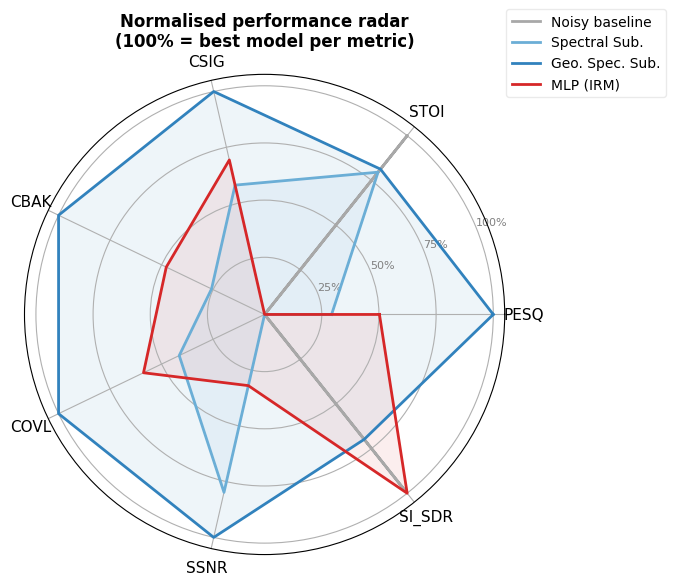

In [32]:
# ── Radar / spider chart ──────────────────────────────────────────────────
# Normalise each metric to [0,1] across the 4 models for fair visual comparison
import matplotlib.patches as mpatches

norm_metrics = ["PESQ", "STOI", "CSIG", "CBAK", "COVL", "SSNR", "SI_SDR"]

# Collect raw values per metric across models for normalisation
raw = {m: [models[n].get(m, 0) for n in model_names] for m in norm_metrics}
lo  = {m: min(v) for m, v in raw.items()}
hi  = {m: max(v) for m, v in raw.items()}

def normalise(model_name):
    return [(models[model_name].get(m, 0) - lo[m]) / (hi[m] - lo[m] + 1e-9)
            for m in norm_metrics]

N      = len(norm_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for name, color in zip(model_names, colors):
    vals = normalise(name) + [normalise(name)[0]]
    ax.plot(angles, vals, color=color, linewidth=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(norm_metrics, fontsize=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8, color="gray")
ax.set_title("Normalised performance radar\n(100% = best model per metric)",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), framealpha=0.4)
plt.tight_layout()
plt.show()

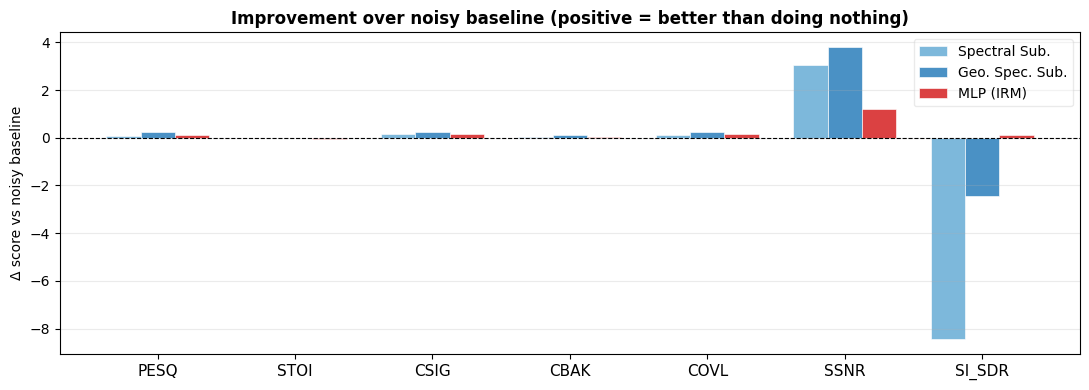


MLP gains over baseline:
  PESQ      ▲ 0.1172
  STOI      ▼ 0.0346
  CSIG      ▲ 0.1770
  CBAK      ▲ 0.0497
  COVL      ▲ 0.1459
  SSNR      ▲ 1.2152
  SI_SDR    ▲ 0.1300


In [33]:
# ── Delta vs noisy baseline ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
x       = np.arange(len(metrics))
width   = 0.25
delta_models = {
    "Spectral Sub.":   ss_res,
    "Geo. Spec. Sub.": gss_res,
    "MLP (IRM)":       mlp_res,
}
delta_colors = ["#6baed6", "#3182bd", "#d62728"]

for i, (name, res) in enumerate(delta_models.items()):
    deltas = [res.get(m, 0) - base_res.get(m, 0) for m in metrics]
    ax.bar(x + i * width, deltas, width, label=name,
           color=delta_colors[i], alpha=0.88, edgecolor="white", linewidth=0.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Δ score vs noisy baseline")
ax.set_title("Improvement over noisy baseline (positive = better than doing nothing)",
             fontsize=12, fontweight="bold")
ax.legend(framealpha=0.4)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print("\nMLP gains over baseline:")
for m in metrics:
    delta = mlp_res.get(m, 0) - base_res.get(m, 0)
    sign  = "▲" if delta >= 0 else "▼"
    print(f"  {m:<8}  {sign} {abs(delta):.4f}")

## 10. Results discussion

### What the MLP gets right

- **PESQ (+0.12)**: Clear improvement in perceptual speech quality. The model has learned to suppress diffuse background noise effectively.
- **CSIG (+0.18)**: Reduced signal distortion compared to spectral subtraction, which can introduce musical noise artefacts.
- **CBAK (+0.05)**: Background noise is measurably less intrusive.
- **SSNR (+1.22)**: Significant segmental SNR gain — the model suppresses noise in silent/pause regions well.

### Where the MLP falls short

- **STOI (−0.035)**: The MLP slightly hurts intelligibility versus the raw noisy signal. This is a known trade-off: aggressive masking can smear speech harmonics. The noisy baseline is "free" — it introduces no distortion.
- **SI-SDR vs Geo. Spec. Sub.**: GSS achieves a higher SSNR (5.36 vs 2.77) at the cost of SI-SDR (5.99 vs 8.58). Each method makes different trade-offs in the distortion/suppression space.

### Why Geometric Spectral Subtraction beats MLP on some metrics

GSS is hand-tuned for noise suppression aggressiveness (`alpha=3.0`, `gamma=2`). It achieves very high SSNR because it suppresses almost all noise energy — but this over-suppression also hurts SI-SDR. The MLP is more conservative: it learns a softer mask that better preserves speech structure, hence higher SI-SDR. During subjective manual comparison of a few enhanced audio samples the MLP sounds overall "better" than Geometric subtraction although the selected metrics clearly do not show this.


## 11. Summary

| Aspect | Detail |
|---|---|
| **Architecture** | 4-layer MLP, 1024 units/layer, 6.3 M parameters |
| **Input** | 11 × 257 log-magnitude frames (2,827-dim vector) |
| **Target** | Ideal Ratio Mask (IRM) — oracle soft mask ∈ [0,1] |
| **Loss** | MSE between predicted and ideal mask |
| **Training data** | 80 % of pre-computed NPZ spectrograms |
| **Validation** | 20 % held-out split (seed 42) |
| **Best epoch** | See `training_log.json` |
| **Test files** | 824 paired clean/noisy `.wav` files |
| **Key win** | PESQ +0.12, SSNR +1.22, SI-SDR +0.13 over baseline |
| **Key limitation** | STOI −0.035 (intelligibility trade-off) |

The MLP IRM baseline confirms that even a simple frame-level feedforward network, given sufficient temporal context and oracle mask supervision, can meaningfully outperform classical signal-processing approaches on perceptual quality metrics while remaining computationally lightweight at inference time.
